# Ayudantía N°2: Tidyverse II
### Funciones `mutate()` + `case_when()` y `rename()`

---

##**Contenidos**
I. Instalación de Paquetes y Carga de Datos

II. Ejercicios `select()`: seleccionar columnas

III. Ejercicios `filter()`: filtrar filas

IV. Aprender **`mutate()`: mutar o modificar**


---

Antes de comenzar recuerda la lógica general:

**Pregunta → ¿Qué necesito hacer con los datos? → Código → Resultado → Interpretación**

## 1. Instalación de paquetes y carga de datos
El paquete tidyverse incluye herramientas como ggplot2, dplyr, tidyr, readr, entre otros.

#### - Podemos aplicar dos formas:

In [ ]:
install.packages("tidyverse")
library(tidyverse)

In [ ]:
install.packages("pacman")
pacman::p_load(tidyverse, readxl)
# estamos cargando dos paquetes: tidyverse y readxl (que sirve para leer archivos Excel)

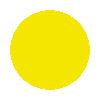
 ### Pacman
pacman facilita la carga y gestión de paquetes en R, permitiendo instalar y cargar múltiples paquetes de manera eficiente. Al utilizar pacman podemos instalar varios paquetes a la vez.

Se debe instalar, luego abrir y ejecutar.

## 2. Cargar base de datos

Utilizaremos la `base_antropologia_limpia.xlsx`, ubicada en el entorno de Google Colab.

* Primero hay que subirla para que podamos encontrarla en el entorno
* Luego se debe abrir utilizando la función `read_excel("/file/base_antropologia_limpia.xlsx")`
* La llamaremos Data

In [ ]:
BASE <- read_excel("/base_antropologia_limpia.xlsx")

## 3. Exploración de la base de datos
Sabemos que explorar una base de datos nos permite comprender la información disponible, detectar patrones y encontrar posibles errores antes de aplicar modelos o tomar decisiones.

Esto es esencial antes de cualquier análisis profundo, ya que nos permite  visualizar y limpiar los datos para tomar mejores decisiones y evitar errores. ¡Siempre es el primer paso en un buen análisis de datos!

Podemos explorar la data con diferentes **funciones**:

`head()`

`glimpse()`

`View()`

`names()`


In [ ]:
glimpse(BASE) # Mirada rápida de los datos

---

## Repaso `tydiverse` I

# **II. `select`**
`select` es una herramienta de `tidyverse` que nos permite **seleccionar columnas**.

**Seleccionamos columnas, es decir, variables** que sean necesarias para el tema que busquemos analizar. Por ejemplo, si buscamos realizar un análisis sobre las horas de estudio y el rendimiento académico, podemos seleccionar variables relacionadas con el tema.


## Estructura del código:

`base <- base %>% select(variable1, variable2)`

## ¡Ejercicio! *Análisis de estrés y rendimiento académico*
Queremos analizar **cómo el estrés puede verse relacionado al rendimiento académico**, por lo que seleccionamos solo las variables relacionadas con estrés y rendimiento.

### 1. **Seleccionar las variables. Aplicar `select()`:**
* `notas_ultimo_semestre_intervalo`
* `ea_05_satisfaccion_rendimiento_academico_r`
* `ea_06_nivel_estres_ultimo_semestre_r`
* `ea_07_efecto_estres_rendimiento_r`

In [ ]:
rendimiento_estres <- BASE %>% select(notas_ultimo_semestre_intervalo, ea_05_satisfaccion_rendimiento_academico_r, ea_06_nivel_estres_ultimo_semestre_r, ea_07_efecto_estres_rendimiento_r)

head(rendimiento_estres)

### 2. **Guardamos la selección realizada en un objeto** llamado **rendimiento_estres**, en el cual exploramos los datos creados con la selección

 Para la exploración aplicaremos:

  * `glimpse()`
  * `names()`

In [ ]:
glimpse(rendimiento_estres)

In [ ]:
names(rendimiento_estres)

#### 🔶 Práctica:
Si quisieras seleccionar solo las variables `edad`, `género` y `horas_estudio`, y guardarlas en un objeto llamado *tiempo_estudio_por_edad_genero* ¿cómo completarías el siguiente código?

In [ ]:
# Completa:

_________ <- BASE %>%
  select(_________, _________, _________)

names()

---

# **III. `filter`**

`filter` es una herramienta de tidyverse que nos permite **filtrar filas.**

**Filtramos filas, es decir casos**, con el fin de obtener datos particulares necesarios para nuestro análisis. Por ejemplo, si necesitamos hacer un análisis de los estudiantes que ingresaron después del año 2020 a la universidad, podemos filtrar y quedarnos únicamente con aquellos estudiantes.    

## Estructura del código:

* En variables categóricas:

    `base <- base %>% filter(variable %in% c("categoría1", "categoría2"))`


* En variables numéricas:

    `base <- base %>% filter(variable_ numérica < = > a Xcategoría_numerica) `


In [ ]:

# Veamos las categorías de respuesta de la variable que queremos filtrar, utilizando la función table()
table(BASE$año_ingreso_carrera)  # Se acuerdan del símbolo $ ?

# Filtrar estudiantes que ingresaron después de 2020
ingreso_2020_mas <- BASE %>%
  filter(año_ingreso_carrera >= 2020)

# Observamos cómo queda
head(ingreso_2020_mas)

#### 🔶 Práctica:
Si quisieras filtrar a los estudiantes que estudian más de 15 horas a la semana, ¿cómo completarías el código?

In [ ]:
# Completa:

estudiantes_dedicados <- _____ %>%
  filter(_________ > ____)

head(estudiantes_dedicados)

# **III. `mutate`**

`mutate` es una herramienta de tidyverse que nos permite **modificar variables con sus categorías de respuesta y crear nuevas variables con categorías que nosotros/as/es definamos.**
  

Para esto, utilizamos la función `mutate()` en conjunto con la función `case_when()`

## Estructura del código:

    `base <- base %>% mutate(variable_nueva = case_when(variable_antigua sea X categoría_antigua ~ categoría_nueva)`


Por ejemplo, en el caso a continuación mutamos la variable *edad* transformándola en otra llamada *categoria_edad* para que sus categorías queden con los **nombres y rangos deseados**.

In [ ]:
# Aplicamos unique para ver las categorías de respuesta de la variable que deseamos mutar
unique(Data)

# Creamos una nueva variable llamada categoria_edad para clasificar edad en rangos
BASE <- BASE %>%
  mutate(categoria_edad = case_when(
    edad < 20 ~ "Menor de 20",
    edad >= 20 & edad < 25 ~ "20-24",
    TRUE ~ "25 o más"
  ))

# Observamos cómo queda
table(BASE$categoria_edad)

#### 🔶 Práctica: Creación de Nueva Variable
Si quisieras crear una variable llamada `categoria_estudio` que clasifique las horas de estudio en "Bajo" (0-5), "Medio" (6-15) y "Alto" (>15), ¿cómo completarías el código?

In [ ]:
# Completa:

BASE <- BASE %>%
  mutate(categoria_estudio = case_when(
    _________ <= 5 ~ "Bajo",
    _________ > 5 & _________ <= 15 ~ "Medio",
    TRUE ~ "Alto"
  ))


  table(BASE$categoria_estudio)
